In [ ]:
import matplotlib.pyplot as plt # For plotting
import numpy as np              # Linear algebra library
import pandas as pd             # For manipulating tabular data
import random                   # for random number generation

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import re

text = "about 3 or 4"

def first_number(text):
  match = re.search(r'-?\d+', str(text))
  if match:
      first_number = int(match.group())
      # print(first_number)  # Output: 42
      return first_number
  else:
      return None

first_number(text)

3

In [ ]:
def categorize_drink(drink_text):
    if pd.isna(drink_text):
        return 'none'

    drink_text = drink_text.lower().strip()

    # Specific drinks
    if 'sake' in drink_text or 'soju' in drink_text:
        return 'asian alcohol'
    elif 'tea' in drink_text:
        return 'tea'
    elif 'ayran' in drink_text or 'lassi' in drink_text or 'yogurt' in drink_text:
        return 'yogurt drink'
    # elif 'coffee' in drink_text or 'espresso' in drink_text:
    #     return 'coffee'
    elif 'coke' in drink_text or 'pepsi' in drink_text or 'cola' in drink_text or 'soda' in drink_text or 'root beer' in drink_text or 'sprite' in drink_text or 'pop' in drink_text or 'ginger ale' in drink_text or 'soft drink' in drink_text or 'fanta' in drink_text:
        return 'soda'
    elif 'wine' in drink_text or 'beer' in drink_text or 'cocktail' in drink_text or 'margarita' in drink_text or 'mojito' in drink_text or 'alcohol' in drink_text:
        return 'other alcohol'
    elif 'juice' in drink_text:
        return 'juice'
    elif 'water' in drink_text:
        return 'water'
    elif 'soup' in drink_text:
        return 'soup'
    elif "don't drink" in drink_text or 'none' in drink_text or 'no drink' in drink_text:
        return 'none'
    else:
        return 'other'


categorize_drink("WaterAAAA")

'water'

In [ ]:
# read each of the csv files as a *pandas data frame*
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cleaned_data_combined.csv")

q2 = 'Q2: How many ingredients would you expect this food item to contain?'
q4 = 'Q4: How much would you expect to pay for one serving of this food item?'
q6 = 'Q6: What drink would you pair with this food item?'
q8 = 'Q8: How much hot sauce would you add to this food item?'
data[q8] = data[q8].replace(pd.NA, 0)
data[q8] = data[q8].replace('A little (mild)', 1)
data[q8] = data[q8].replace('A moderate amount (medium)', 2)
data[q8] = data[q8].replace('A lot (hot)', 3)
data[q8] = data[q8].replace('I will have some of this food item with my hot sauce', 4)

# replace q2 and q4 data columns with the first number that appears
data[q2] = data[q2].apply(first_number)
data[q4] = data[q4].apply(first_number)

# categorize drinks into usable data
data[q6] = data[q6].apply(categorize_drink)

# fill NaN with mean
data[q2] = data[q2].fillna(
    data.groupby('Label')[q2].transform('mean')
)

data[q4] = data[q4].fillna(
    data.groupby('Label')[q4].transform('mean')
)

# convert labels to numbers for Logistic Regression
data['Label'] = data['Label'].replace('Pizza', 0)
data['Label'] = data['Label'].replace('Shawarma', 1)
data['Label'] = data['Label'].replace('Sushi', 2)

# display one the dataframes in the notebook
data

<ipython-input-5-7a78d5115c42>:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[q8] = data[q8].replace('I will have some of this food item with my hot sauce', 4)
<ipython-input-5-7a78d5115c42>:33: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Label'] = data['Label'].replace('Sushi', 2)


,id,"Q1: From a scale 1 to 5, how complex is it to make this food? (Where 1 is the most simple, and 5 is the most complex)",Q2: How many ingredients would you expect this food item to contain?,Q3: In what setting would you expect this food to be served? Please check all that apply,Q4: How much would you expect to pay for one serving of this food item?,Q5: What movie do you think of when thinking of this food item?,Q6: What drink would you pair with this food item?,"Q7: When you think about this food item, who does it remind you of?",Q8: How much hot sauce would you add to this food item?,Label
0,716549,3,6.000000,"Week day lunch,At a party,Late night snack",5.0,Cloudy with a Chance of Meatballs,soda,Friends,1,0
1,715742,4,5.946050,"Week day lunch,At a party,Late night snack",5.0,All sort of american young boy movies,soda,"Friends,Teachers,Strangers",0,0
2,727333,3,5.000000,"Week day lunch,Week day dinner,Weekend lunch,W...",10.0,action movie,soda,Friends,2,0
3,606874,4,6.000000,"Week day lunch,Week day dinner,Weekend lunch,W...",3.0,Mamma Mia,soda,"Siblings,Friends,Teachers",4,0
4,505318,2,3.000000,"Week day lunch,Week day dinner,Weekend lunch,W...",5.0,Cloudy with a chance of meatballs,soda,"Siblings,Friends",1,0
...,...,...,...,...,...,...,...,...,...,...
1639,413395,2,3.000000,"Week day dinner,Weekend dinner",5.0,Romantic Movies,soup,"Parents,Siblings,Friends",0,2
1640,386750,3,4.000000,"Week day lunch,Weekend lunch",12.0,One Piece Film Gold,water,Friends,1,2
1641,617178,2,4.594231,"Week day lunch,Weekend lunch,At a party",10.0,I think of the anime Food Wars,water,Parents,0,2
1642,630128,1,3.000000,"Week day lunch,Weekend lunch,Late night snack",1.0,John Wick 3,tea,"Siblings,Friends,Strangers",1,2


In [ ]:
# Re-import necessary libraries after code execution state reset
import pandas as pd
import numpy as np

# Prepare data from the existing DataFrame: (review, label) pairs
movie_reviews = data["Q5: What movie do you think of when thinking of this food item?"].fillna("").astype(str).str.lower()
food_labels = data["Label"]

# Create list of (review, label) pairs
movie_data = list(zip(movie_reviews, food_labels))

# Build vocabulary (simple token split, no stopwords removal or punctuation filtering for now)
tokenized_reviews = [set(review.split()) for review, _ in movie_data]
vocab_set = set(word for tokens in tokenized_reviews for word in tokens)
vocab = sorted(vocab_set)

# Function adapted from user's template
def make_bow(data, vocab):
    X = np.zeros([len(data), len(vocab)], dtype=int)
    t = []

    word_index = {word: idx for idx, word in enumerate(vocab)}  # fast lookup

    for i, (review, label) in enumerate(data):
        words = set(review.split())
        for word in words:
            if word in word_index:
                X[i, word_index[word]] = 1
        t.append(label)

    return X, np.array(t)

# Run function
X_bow, t_labels = make_bow(movie_data, vocab)

# Show shape for confirmation
X_bow_custom.shape, t_labels.shape


((1644, 1187), (1644,))

In [ ]:
food_complexity = "Q1: From a scale 1 to 5, how complex is it to make this food? (Where 1 is the most simple, and 5 is the most complex)"

setting = "Q3: In what setting would you expect this food to be served? Please check all that apply"
drinks = "Q6: What drink would you pair with this food item?"
person = "Q7: When you think about this food item, who does it remind you of?"
hot_sauce = "Q8: How much hot sauce would you add to this food item?"
data_fets = np.stack([
    # 5 choices for food complexity
    data[food_complexity] == 1,
    data[food_complexity] == 2,
    data[food_complexity] == 3,
    data[food_complexity] == 4,
    data[food_complexity] == 5,

    # 5 choices for hot sauce
    data[hot_sauce] == 0,
    data[hot_sauce] == 1,
    data[hot_sauce] == 2,
    data[hot_sauce] == 3,
    data[hot_sauce] == 4,

    # 7 categories, for each type of setting including None
    data[setting].str.contains("Week day lunch", na=False).astype(int),
    data[setting].str.contains("Week day dinner", na=False).astype(int),
    data[setting].str.contains("Weekend lunch", na=False).astype(int),
    data[setting].str.contains("Weekend dinner", na=False).astype(int),
    data[setting].str.contains("At a party", na=False).astype(int),
    data[setting].str.contains("Late night snack", na=False).astype(int),
    data[setting] == pd.NA,

    # 6 categories for each type of person and None
    data[person].str.contains("Parents", na=False).astype(int),
    data[person].str.contains("Siblings", na=False).astype(int),
    data[person].str.contains("Friends", na=False).astype(int),
    data[person].str.contains("Teachers", na=False).astype(int),
    data[person].str.contains("Strangers", na=False).astype(int),
    data[person] == pd.NA,

    # 10 categories for drinks
    data[drinks].str.contains("soda", na=False).astype(int),
    data[drinks].str.contains("water", na=False).astype(int),
    data[drinks].str.contains("tea", na=False).astype(int),
    data[drinks].str.contains("other", na=False).astype(int),
    data[drinks].str.contains("juice", na=False).astype(int),
    data[drinks].str.contains("asian alcohol", na=False).astype(int),
    data[drinks].str.contains("other alcohol", na=False).astype(int),
    data[drinks].str.contains("soup", na=False).astype(int),
    data[drinks].str.contains("yogurt drink", na=False).astype(int),
    data[drinks].str.contains("none", na=False).astype(int),

    # numerical features
    data["Q2: How many ingredients would you expect this food item to contain?"],
    data["Q4: How much would you expect to pay for one serving of this food item?"]
], axis=1)

# Convert sparse BoW to dense (only if memory permits)
# bow_dense = X_bow.toarray()

# Sanity check: shapes should align on axis 0
assert data_fets.shape[0] == X_bow.shape[0]

# Concatenate along columns (axis=1)
data_fets = np.concatenate([X_bow, data_fets], axis=1)

# Confirm shape
print("Combined feature shape:", X_bow.shape)


print(data_fets.shape) # Should be (1644, 35)

Combined feature shape: (1644, 1187)
(1644, 1222)


In [ ]:
feature_names = [
    "Not complex",
    "Slightly complex",
    "Moderately complex",
    "Pretty complex",
    "Very complex",
    "No hot sauce",
    "A bit of hot sauce",
    "A moderate amount of hot sauce",
    "A lot of hot sauce",
    "Food? Only hot sauce",
    "Week day lunch",
    "Week day dinner",
    "Weekend lunch",
    "Weekend dinner",
    "At a party",
    "Late night snack",
    "No setting",
    "Parents",
    "Siblings",
    "Friends",
    "Teachers",
    "Strangers",
    "Nobody",
    "soda",
    "water",
    "tea",
    "other",
    "juice",
    "asian alcohol",
    "other alcohol",
    "soup",
    "yogurt drink",
    "none",
    "number of ingredients",
    "cost"
    ]

  # Get the BoW feature names
# bow_feature_names = vectorizer.get_feature_names_out()

# Combine the two
feature_names = list(bow_feature_names) + feature_names

# Show total count and a preview
len(feature_names), feature_names[:40], feature_names[-10:]

(1017,
 ['007',
  '10',
  '1001',
  '11',
  '13',
  '1953',
  '2001',
  '2002',
  '2004',
  '2005',
  '2006',
  '2008',
  '2012',
  '2014',
  '2016',
  '2018',
  '2021',
  '2022',
  '2024',
  '21',
  '30',
  '3d',
  '47',
  '85',
  'about',
  'abyss',
  'academia',
  'across',
  'action',
  'actually',
  'advengers',
  'after',
  'again',
  'age',
  'air',
  'aladdin',
  'alien',
  'aliens',
  'alita',
  'all'],
 ['tea',
  'other',
  'juice',
  'asian alcohol',
  'other alcohol',
  'soup',
  'yogurt drink',
  'none',
  'number of ingredients',
  'cost'])

Like before, we can separate our data into training, validation, and test sets.
We will use the same code as we did in lab 2. Just like in lab 2, we will
normalize our data set since some of the classifiers we use will depend on it.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into X (dependent variables) and t (response variable)
X = data_fets
t = np.array(data["Label"])

# First, we will use `train_test_split` to split the data set into
# 6500 training+validation, and 1500 test:
X_tv, X_test, t_tv, t_test = train_test_split(X, t, test_size=274/1644, random_state=1)

# Then, use `train_test_split` to split the training+validation data
# into 5000 train and 1500 validation
X_train, X_valid, t_train, t_valid= train_test_split(X_tv, t_tv, test_size=274/1370, random_state=1)

# Normalization
numerical_value_start = -2
numerical_value_end = 35
# print(X_train[:, numerical_value_start:])
mean = X_train[:, numerical_value_start:].mean(axis=0)
std = X_train[:, numerical_value_start:].std(axis=0)

X_train_norm = X_train.copy()
X_valid_norm = X_valid.copy()
X_test_norm = X_test.copy()
X_train_norm[:, numerical_value_start:] = (X_train[:, numerical_value_start:] - mean) / std
X_valid_norm[:, numerical_value_start:] = (X_valid[:, numerical_value_start:] - mean) / std
X_test_norm[:, numerical_value_start:] = (X_test[:, numerical_value_start:] - mean) / std
print(X_valid_norm)

[[ 0.          0.          0.         ...  0.         -1.02701762
  -1.00987169]
 [ 0.          0.          0.         ...  0.          3.27826562
  -0.13287151]
 [ 0.          0.          0.         ...  0.         -1.02701762
  -0.86370499]
 ...
 [ 0.          0.          0.         ...  0.          0.4080768
   0.45179528]
 [ 0.          0.          0.         ...  0.         -1.02701762
  -0.13287151]
 [ 0.          0.          0.         ...  0.         -0.66824401
  -0.4252049 ]]


Now, we are ready to build some models to understand the various sources of error.
We will work with these three classifiers, which we have previously experimented with.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

**Graded Task**: Complete the function below, which fits a classifier several
times, each time sampling a small training set (without replacement) from
`X_train_norm`.

In [ ]:
def estimate_variance(model, ntries=100, nsample=200):
    """
    Estimate the variance of a classifier on the NHANES data set.

    Parameters:
        `model` - an sklearn model supporting the methods fit(),
                  predict(), and score()
        `ntries` - number of times to train the classifier to compute
                   the classifier's variance.
        `nsamples` - number of data points to sample to train each
                     classifier

    Returns: A tuple containing the average training error,
             average validation error, and variance estimate.
    """
    train_acc = []
    val_acc = []
    ys = []
    for i in range(ntries):
        subset = random.sample(range(1096), nsample)
        model.fit(X_train_norm[subset], t_train[subset])
        ys.append(model.predict(X_valid_norm))
        # print(model.predict(X_valid_norm))
        train_acc.append(model.score(X_train_norm[subset], t_train[subset]))
        val_acc.append(model.score(X_valid_norm, t_valid))
    ys = np.stack(ys)
    # print(ys)
    variances = np.var(ys, axis=0) # TODO: Compute the variance of each row of ys, i.e., for
                     #       each validation data point separate. (Why? Why can't
                     #       we compute the variance of the entire ys?)
    train_error = 1 - np.mean(train_acc) # TODO: the average training error across the ntries models
    val_error = 1 - np.mean(val_acc) # TODO: the average validation error across the ntries models
    return train_error, val_error, variances.mean()

**Task**: Run the code below to explore how the `C` parameter
of a `LogisticRegression` affects the training error, validation error,
and variance.

In [ ]:
cs_res = []
cs = np.arange(-5, 2, 0.2)

for c_exp in cs:
    model = LogisticRegression(random_state=0, penalty='l2', C=10**(c_exp), max_iter=500)
    train_error, val_error, variance = estimate_variance(model)
    cs_res.append([train_error, val_error, variance])

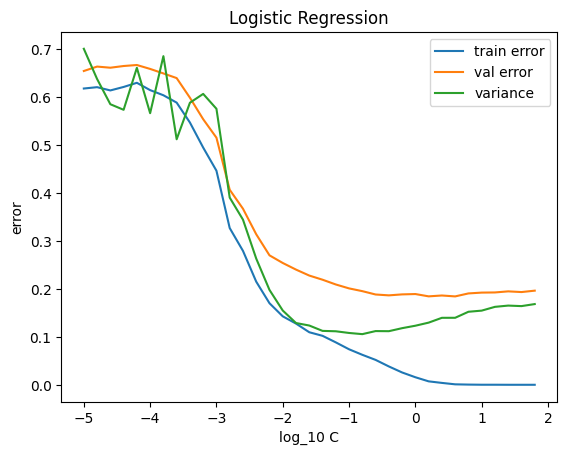

In [ ]:
plt.title("Logistic Regression")
plt.plot(cs, [r[0] for r in cs_res], label="train error")
plt.plot(cs, [r[1] for r in cs_res], label="val error")
plt.plot(cs, [r[2] for r in cs_res], label="variance")
plt.ylabel("error")
plt.xlabel("log_10 C")
plt.legend()
plt.show()

**Task**: How does the `C` parameter affect the training error, validation error,
and variance of the trained model?

In [ ]:
# TODO
# For all 3, as C increases, the error decreases. Though variance seems to start steadily increaseing
# after log_10 C = -1

In [ ]:
mlp_res = []
hidden_sizes = range(1, 21)

for h in hidden_sizes:
    model = MLPClassifier(alpha=0,                 # set regularization parameter to 0
                          hidden_layer_sizes=(h,), # use only 1 hidden layer with h units
                          learning_rate_init=0.1,  # increase LR from the default
                          max_iter=200)
    train_error, val_error, variance = estimate_variance(model, ntries=10)
    mlp_res.append([train_error, val_error, variance])

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


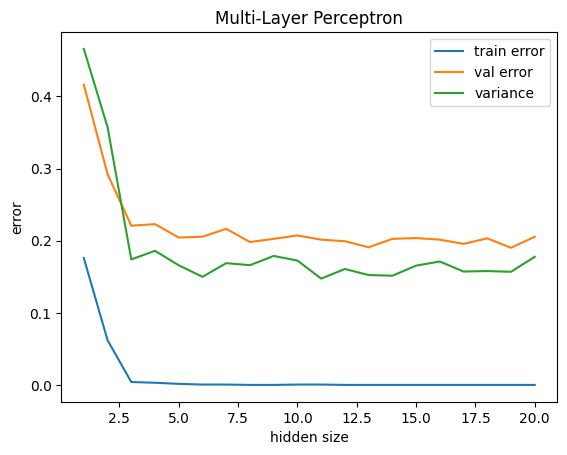

In [ ]:
plt.title("Multi-Layer Perceptron")
plt.plot(hidden_sizes, [r[0] for r in mlp_res], label="train error")
plt.plot(hidden_sizes, [r[1] for r in mlp_res], label="val error")
plt.plot(hidden_sizes, [r[2] for r in mlp_res], label="variance")
plt.ylabel("error")
plt.xlabel("hidden size")
plt.legend()
plt.show()

**Task**: Run the code below to explore how the `max_depth` parameter
of a `DecisionTreeClassifier` affects the training error, validation error,
and variance.

In [ ]:
tree_res = []
depths = list(range(1,21))
for max_depth in depths:
    model = DecisionTreeClassifier(random_state=0, max_depth=max_depth)
    train_error, val_error, variance = estimate_variance(model)
    tree_res.append([train_error, val_error, variance])

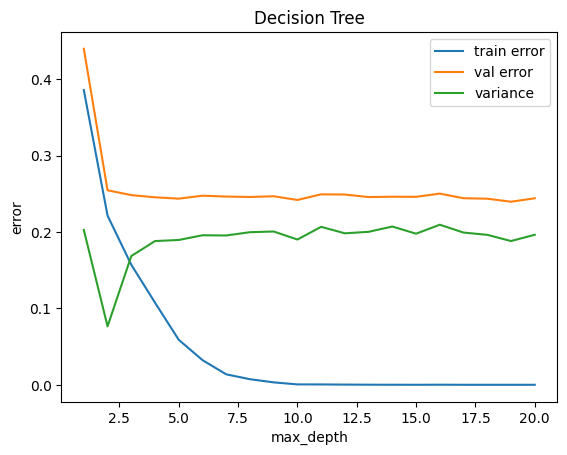

In [ ]:
plt.title("Decision Tree")
plt.plot(depths, [r[0] for r in tree_res], label="train error")
plt.plot(depths, [r[1] for r in tree_res], label="val error")
plt.plot(depths, [r[2] for r in tree_res], label="variance")
plt.ylabel("error")
plt.xlabel("max_depth")
plt.legend()
plt.show()

In [ ]:
def model_averaging(model, ntries=100, nsample=200):
    """
    Fits model a number of times on a subset of the NHANES data
    set, and returns the average validation error of the
    individual models, along with the validation error of the
    average prediction of the models.

    Parameters:
        `model` - an sklearn model supporting the methods fit(),
                  predict(), and score()
        `ntries` - number of times to train the classifier
        `nsamples` - number of data points to sample to train each
                     classifier

    Returns: A tuple containing the average validation error
             across the individual models, and the validation
             error of the average prediction of the models.
    """

    train_acc = []
    val_acc = []
    ys = []
    for i in range(ntries):
        subset = random.sample(range(1096), nsample)
        model.fit(X_train_norm[subset], t_train[subset])
        ys.append(model.predict(X_valid_norm))
        train_acc.append(model.score(X_train_norm[subset], t_train[subset]))
        val_acc.append(model.score(X_valid_norm, t_valid))
    ys = np.stack(ys)

    # compute the average validation error across the individual models
    avg_val_error = 1 - np.mean(val_acc)

    # compute the average prediction across all models, and convert
    # into a discrete prediction (0 or 1 for each data point in the
    # validation set)
    ys_average = np.mean(ys,axis=0)
    ys_average = np.round(ys_average).astype(int)

    # compute the validation error using ys_average and t_valid
    ensemble_val_error  = np.mean(ys_average != t_valid)

    return avg_val_error, ensemble_val_error


print(model_averaging(DecisionTreeClassifier(random_state=0, max_depth=10)))

(np.float64(0.2434671532846715), np.float64(0.24087591240875914))


**Task**: Run the code below, which uses the function we wrote to
analyze how model averaging affects the validation error.

In [ ]:
print("====== Logistic Regression Models ======")
cs = np.arange(-5, 2, 0.2)
for c_exp in cs:
    model = LogisticRegression(random_state=0, penalty='l2', C=10**(c_exp), max_iter=500)
    avg_val_error, ensemble_val_error = model_averaging(model)
    print(f"C=10**{c_exp}", avg_val_error, ensemble_val_error)

====== Logistic Regression Models ======
C=10**-5.0 0.6665328467153284 0.6715328467153284
C=10**-4.8 0.6587591240875913 0.6715328467153284
C=10**-4.6 0.658065693430657 0.6715328467153284
C=10**-4.3999999999999995 0.6669708029197081 0.6715328467153284
C=10**-4.199999999999999 0.6593430656934307 0.6715328467153284
C=10**-3.999999999999999 0.6512773722627738 0.6715328467153284
C=10**-3.799999999999999 0.6410218978102191 0.6715328467153284
C=10**-3.5999999999999988 0.6237956204379562 0.6678832116788321
C=10**-3.3999999999999986 0.5975547445255474 0.5437956204379562
C=10**-3.1999999999999984 0.5555839416058395 0.5218978102189781
C=10**-2.9999999999999982 0.4922262773722629 0.4854014598540146
C=10**-2.799999999999998 0.42025547445255473 0.3686131386861314
C=10**-2.599999999999998 0.3658394160583942 0.34306569343065696
C=10**-2.3999999999999977 0.3004014598540147 0.3029197080291971
C=10**-2.1999999999999975 0.2740875912408761 0.3029197080291971
C=10**-1.9999999999999973 0.25324817518248177 0.

In [ ]:
print("====== Decision Trees ======")
depths = list(range(1,21))
for max_depth in depths:
    model = DecisionTreeClassifier(random_state=0, max_depth=max_depth)
    avg_val_error, ensemble_val_error = model_averaging(model)
    print(f"max_depth={max_depth}", avg_val_error, ensemble_val_error)

====== Decision Trees ======
max_depth=1 0.4406204379562042 0.4489051094890511
max_depth=2 0.2591605839416057 0.24087591240875914
max_depth=3 0.24594890510948897 0.24087591240875914
max_depth=4 0.2455839416058393 0.22627737226277372
max_depth=5 0.24306569343065687 0.21897810218978103
max_depth=6 0.24656934306569323 0.22627737226277372
max_depth=7 0.24401459854014573 0.23722627737226276
max_depth=8 0.2458759124087594 0.22992700729927007
max_depth=9 0.2472627737226274 0.24452554744525548
max_depth=10 0.24514598540145982 0.22627737226277372
max_depth=11 0.24773722627737227 0.23722627737226276
max_depth=12 0.25124087591240885 0.22992700729927007
max_depth=13 0.2393065693430657 0.21532846715328466
max_depth=14 0.2488321167883213 0.24452554744525548
max_depth=15 0.2475182481751823 0.24452554744525548
max_depth=16 0.24784671532846703 0.2518248175182482
max_depth=17 0.25080291970802915 0.25547445255474455
max_depth=18 0.2444890510948905 0.22992700729927007
max_depth=19 0.2471897810218977 0.237

In [ ]:
# The MLP code is also included. You can optionally uncomment
# and run this code for your interest. However, these models tend to be more
# expensive to train, and are less often used in an ensemble.

print("====== MultiLayer Perceptrons  ======")
hidden_sizes = range(1, 21)
for h in hidden_sizes:
    model = MLPClassifier(alpha=0,  # regularization parameter
                          hidden_layer_sizes=(h,),
                          learning_rate_init=0.01,
                          max_iter=1000)
    avg_val_error, ensemble_val_error = model_averaging(model, ntries=10)
    print(f"hidden_size={h}", avg_val_error, ensemble_val_error)

====== MultiLayer Perceptrons  ======
hidden_size=1 0.44890510948905105 0.46715328467153283
hidden_size=2 0.2883211678832116 0.2737226277372263
hidden_size=3 0.3003649635036496 0.30656934306569344
hidden_size=4 0.28065693430656924 0.23722627737226276


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


hidden_size=5 0.28284671532846706 0.23722627737226276
hidden_size=6 0.2766423357664234 0.25547445255474455
hidden_size=7 0.260948905109489 0.28102189781021897
hidden_size=8 0.2620437956204379 0.27007299270072993
hidden_size=9 0.27591240875912404 0.28102189781021897
hidden_size=10 0.2682481751824818 0.24452554744525548
hidden_size=11 0.26605839416058397 0.2518248175182482
hidden_size=12 0.2766423357664233 0.24452554744525548
hidden_size=13 0.260948905109489 0.26277372262773724
hidden_size=14 0.2536496350364963 0.24817518248175183
hidden_size=15 0.2627737226277371 0.25547445255474455
hidden_size=16 0.2656934306569344 0.26277372262773724
hidden_size=17 0.2562043795620438 0.24087591240875914
hidden_size=18 0.25072992700729935 0.26277372262773724
hidden_size=19 0.24671532846715327 0.2518248175182482
hidden_size=20 0.24598540145985404 0.22627737226277372


**Task**: Analyze the pattern above.
You should see that ensemble models tend to
perform better or the individual models.
Discuss the patterns you see as to which models tend to achieve
lower validation error in an ensemble,
and the amount of variance and total error that these models tend
to have (from the previous results).

In [ ]:
# TODO
# Decision Trees tend to achieve lower validation error in an ensemble. Tends to have very
# low variance (at higher max depth) with total error staying fairly constant.

You should see that decision trees perform quite well as an ensemble.
We discussed during lecture that individual trees are rarely used
in practice, but that an ensemble of trees tend to work well with little
tuning. Let's now explore the `RandomForestClassifier`, which trains
an ensemble of trees, with some additional randomness baked into
the model to make the predictions less correlated.


**Task**: Run the below code, which explores how the number of
individual trees in a random forest classifier affects the
training error, validation error, and variance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_res = []
num_trees = [1, 2, 5, 10, 25, 50]
for n in num_trees:
    model = RandomForestClassifier(n_estimators=n)
    train_error, val_error, variance = estimate_variance(model, ntries=10, nsample=1000)
    forest_res.append([train_error, val_error, variance])

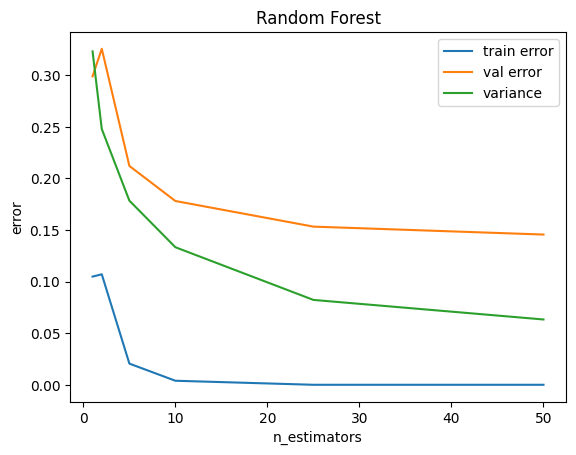

In [ ]:
plt.title("Random Forest")
plt.plot(num_trees, [r[0] for r in forest_res], label="train error")
plt.plot(num_trees, [r[1] for r in forest_res], label="val error")
plt.plot(num_trees, [r[2] for r in forest_res], label="variance")
plt.ylabel("error")
plt.xlabel("n_estimators")
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 10, 20, None],
    'min_samples_split': randint(2, 128),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2']
}

clf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    clf, param_distributions=param_dist, n_iter=50, cv=3,
    scoring='accuracy', n_jobs=-1, random_state=42
)

random_search.fit(X_train, t_train)

print("Best parameters:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)


Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 20, 'n_estimators': 100}
Best CV score: 0.8859670134990143


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 10, 20, None],
    'min_samples_split': [2, 16, 64, 128],
    'min_samples_leaf': [1, 4],
    'max_features': ['sqrt']
}

clf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(clf, param_grid, cv=5, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, t_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)


Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 16, 'n_estimators': 100}
Best CV score: 0.8941926110419262


In [ ]:
model = RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=16)
model.fit(X_train_norm, t_train)
print("Training Accuracy:", model.score(X_train_norm, t_train))
print("Validation Accuracy:", model.score(X_valid_norm, t_valid))
print("Test Accuracy:", model.score(X_test_norm, t_test))

Training Accuracy: 0.968065693430657
Validation Accuracy: 0.8576642335766423
Test Accuracy: 0.9379562043795621


In [ ]:
# label_map = {
#     0: "Pizza",
#     1: "Shawarma",
#     2: "Sushi"
# }
# preds = model.predict(data_fets)  # or model.predict(X_test)
# for num in preds:
#   print(label_map[num])              # prints array of predicted class labels

In [ ]:
def extract_tree(model):
    tree = model.tree_
    return {
        "children_left": tree.children_left.tolist(),
        "children_right": tree.children_right.tolist(),
        "feature": tree.feature.tolist(),
        "threshold": tree.threshold.tolist(),
        "value": tree.value.tolist()  # class counts per leaf
    }


In [ ]:
import json

forest_data = [extract_tree(tree) for tree in model.estimators_]

with open("random_forest_trees.json", "w") as f:
    json.dump(forest_data, f)

In [ ]:
"""
This Python file is example of how your `pred.py` script should
look. Your file should contain a function `predict_all` that takes
in the name of a CSV file, and returns a list of predictions.

Your `pred.py` script can use different methods to process the input
data, but the format of the input it takes and the output your script produces should be the same.

Here's an example of how your script may be used in our test file:

    from example_pred import predict_all
    predict_all("example_test_set.csv")
"""

# basic python imports are permitted
import sys
import csv
import random

# numpy and pandas are also permitted
import numpy
import pandas

label_map = {
    0: "Pizza",
    1: "Shawarma",
    2: "Sushi"
}

def predict(x):
    """
    Helper function to make prediction for a given input x.
    This code is here for demonstration purposes only.
    """
    # randomly choose between the three choices: 'Pizza', 'Shawarma', 'Sushi'.
    # NOTE: make sure to be *very* careful of the spelling/capitalization of the cities!!
    y = predict_forest(x, forest_data)

    # return the prediction
    return y


def predict_all(filename):
    """
    Make predictions for the data in filename
    """
    # read the file containing the test data
    # you do not need to use the "csv" package like we are using
    # (e.g. you may use numpy, pandas, etc)
    data = pd.read_csv(open(filename))
    data = preprocess_data(data)
    data = encode_data(data)
    print(data.shape)

    predictions = model.predict(data_fets)  # or model.predict(X_test)
    # Map numeric predictions to string labels
    predictions = [label_map[p] for p in predictions]

    return predictions

In [ ]:
accuracy(predict_all('/content/drive/MyDrive/Colab Notebooks/cleaned_data_combined.csv'))

(1644, 35)
['Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza', 'Pizza'

<ipython-input-159-13e6e212fdd2>:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[q8] = data[q8].replace('I will have some of this food item with my hot sauce', 4)
<ipython-input-159-13e6e212fdd2>:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Label'] = data['Label'].replace('Sushi', 2)
<ipython-input-159-13e6e212fdd2>:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to

0.8570559610705596

In [ ]:
def accuracy(pred):
  data = pd.read_csv(open('/content/drive/MyDrive/Colab Notebooks/cleaned_data_combined.csv'))
  data = preprocess_data(data)
  true = data['Label']
  true = [label_map[p] for p in true]
  print(true)
  correct = sum(p == t for p, t in zip(pred, true))
  return correct / len(true)